# Telco Customer Churn — Exploratory Data Analysis

This notebook inspects the [Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) to understand which customer factors correlate most with leaving.

Model training lives in `train.py`; this notebook focuses on data inspection and simple visual analysis only.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from train import load_data

sns.set_theme(style="whitegrid")

## 1. Setup & Data Loading

The dataset has **21 columns**: 19 input features, `customerID` (identifier), and `Churn` (target).

**Demographics**
- `gender`, `SeniorCitizen`, `Partner`, `Dependents`

**Account information**
- `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`

**Services**
- `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`

In [2]:
df = load_data()

print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df.head()

Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_tc = df['TotalCharges'].isna().sum()
print(f"Missing TotalCharges after coercion: {missing_tc}")
if missing_tc:
    print(df.loc[df['TotalCharges'].isna(), ['tenure', 'MonthlyCharges', 'TotalCharges']].head())
    print("These are new customers (tenure=0). We impute with median for analysis, same as train.py.")

Missing TotalCharges after coercion: 11
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
These are new customers (tenure=0). We impute with median for analysis, same as train.py.


## 2. Target Variable: Churn & Class Imbalance

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: object


/tmp/ipykernel_33547/1436974363.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', order=['No', 'Yes'], palette=['#4C78A8', '#F58518'])


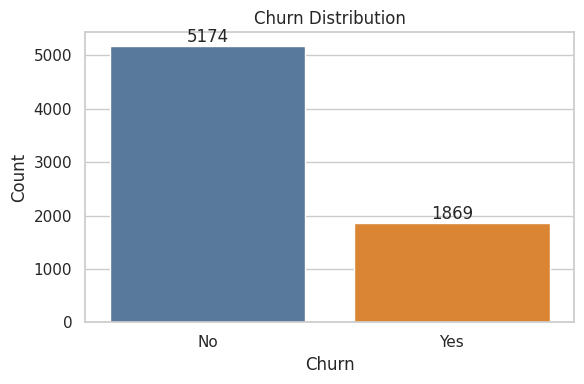

In [6]:
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(df['Churn'].value_counts())
print(churn_pct.round(1).astype(str) + '%')

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', order=['No', 'Yes'], palette=['#4C78A8', '#F58518'])
ax.set_title('Churn Distribution')
ax.set_ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

Most customers stay (~73% No / ~27% Yes), so **accuracy alone is misleading**. Model evaluation uses **F1-Score** and **ROC-AUC** in `train.py`.

## 3. Analysis Helpers

In [7]:
analysis_df = df.copy()
analysis_df['ChurnFlag'] = analysis_df['Churn'].map({'Yes': 1, 'No': 0})
analysis_df['TotalCharges'] = analysis_df['TotalCharges'].fillna(analysis_df['TotalCharges'].median())


def churn_rate_bar(ax, data, column, title=None):
    rates = data.groupby(column)['ChurnFlag'].mean().sort_values(ascending=False) * 100
    rates.plot(kind='bar', ax=ax, color='#E45756')
    ax.set_title(title or f'Churn rate by {column}')
    ax.set_ylabel('Churn rate (%)')
    ax.set_xlabel(column)
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')
    return rates


def churn_hist(ax, data, column):
    for label, color in [('No', '#4C78A8'), ('Yes', '#F58518')]:
        subset = data.loc[data['Churn'] == label, column]
        ax.hist(subset, bins=25, alpha=0.6, label=f'Churn={label}', color=color)
    ax.set_title(f'{column} by churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Count')
    ax.legend()


def plot_churn_bars(data, columns, ncols=2, figsize=(12, 8), titles=None):
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    results = {}
    for i, col in enumerate(columns):
        title = titles.get(col) if titles else None
        results[col] = churn_rate_bar(axes[i], data, col, title=title)
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()
    return results

## 4. Demographics

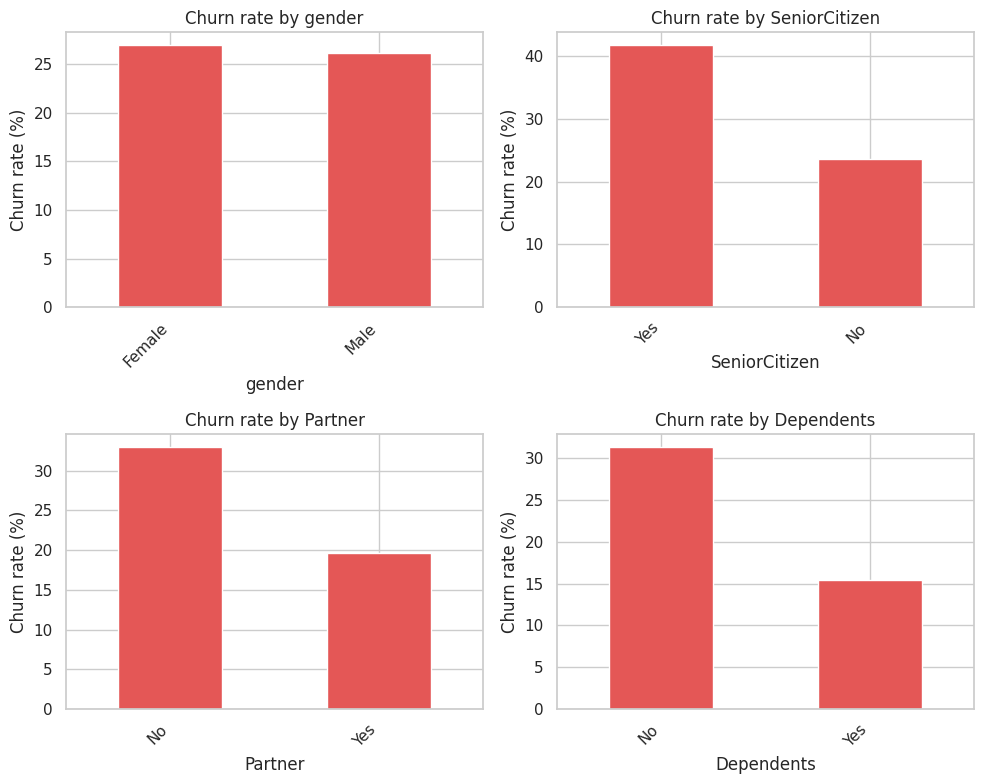

In [8]:
senior_df = analysis_df.copy()
senior_df['SeniorCitizen'] = senior_df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
demo_results = plot_churn_bars(senior_df, ['gender', 'SeniorCitizen', 'Partner', 'Dependents'], ncols=2, figsize=(10, 8))

Senior citizens and customers without a partner or dependents churn more. Gender alone shows little difference.

## 5. Account Information

### Categorical

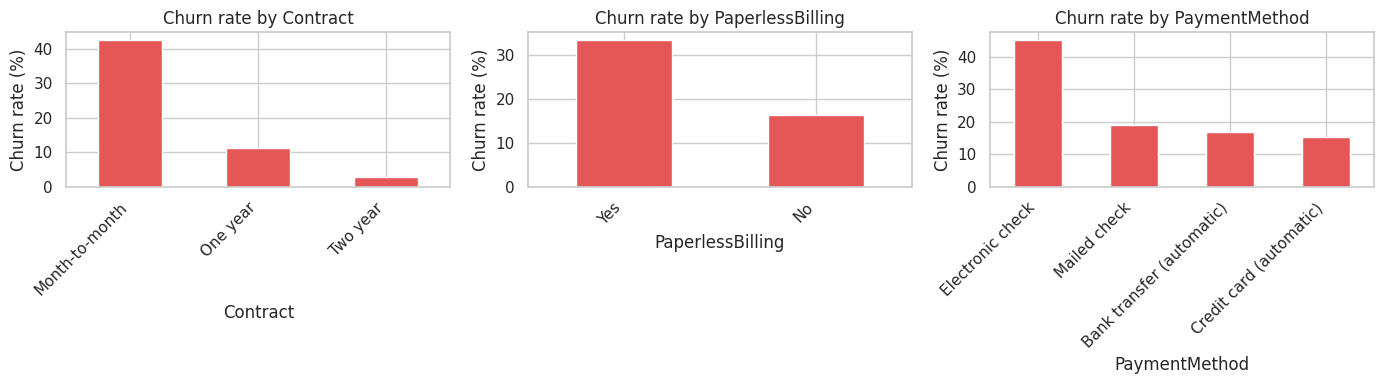

In [9]:
account_cat_results = plot_churn_bars(
    analysis_df,
    ['Contract', 'PaperlessBilling', 'PaymentMethod'],
    ncols=3,
    figsize=(14, 4),
)

**Month-to-month contracts** have much higher churn than 1- or 2-year contracts.

**Electronic check** payers churn more than customers on automatic payment.

### Numeric

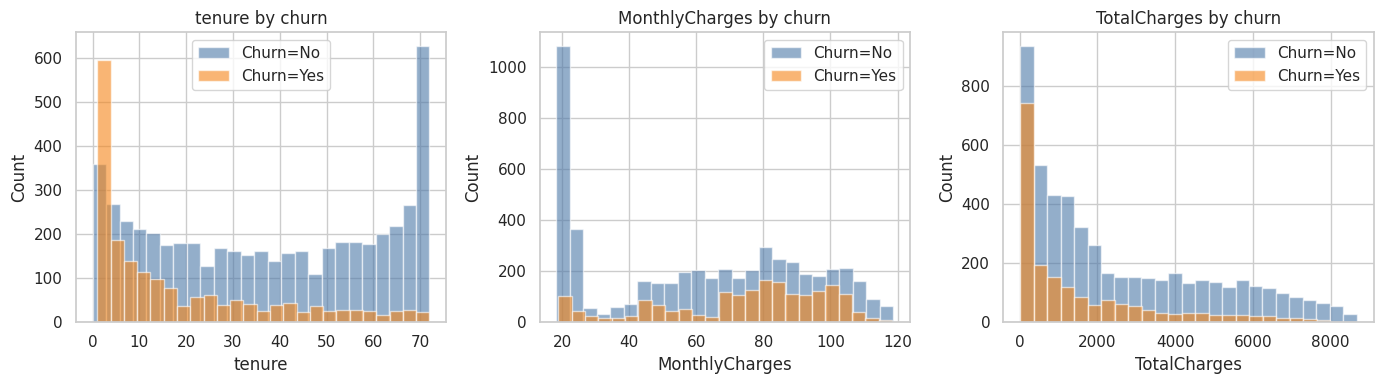

Correlation with churn:
tenure           -0.352
TotalCharges     -0.199
MonthlyCharges    0.193
SeniorCitizen     0.151
Name: ChurnFlag, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    churn_hist(ax, analysis_df, col)
plt.tight_layout()
plt.show()

numeric_corr = analysis_df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'ChurnFlag']].corr()['ChurnFlag'].drop('ChurnFlag')
print('Correlation with churn:')
print(numeric_corr.sort_values(key=abs, ascending=False).round(3))

**Lower tenure** and **higher monthly charges** correlate with churn. Low total charges mainly reflect short tenure.

## 6. Phone Services

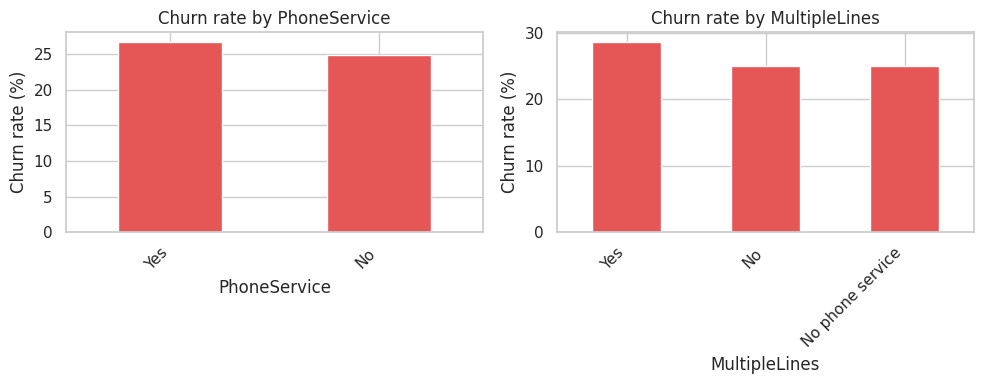

In [11]:
phone_results = plot_churn_bars(analysis_df, ['PhoneService', 'MultipleLines'], ncols=2, figsize=(10, 4))

Phone service attributes show smaller churn differences than contract or internet type.

## 7. Internet & Add-on Services

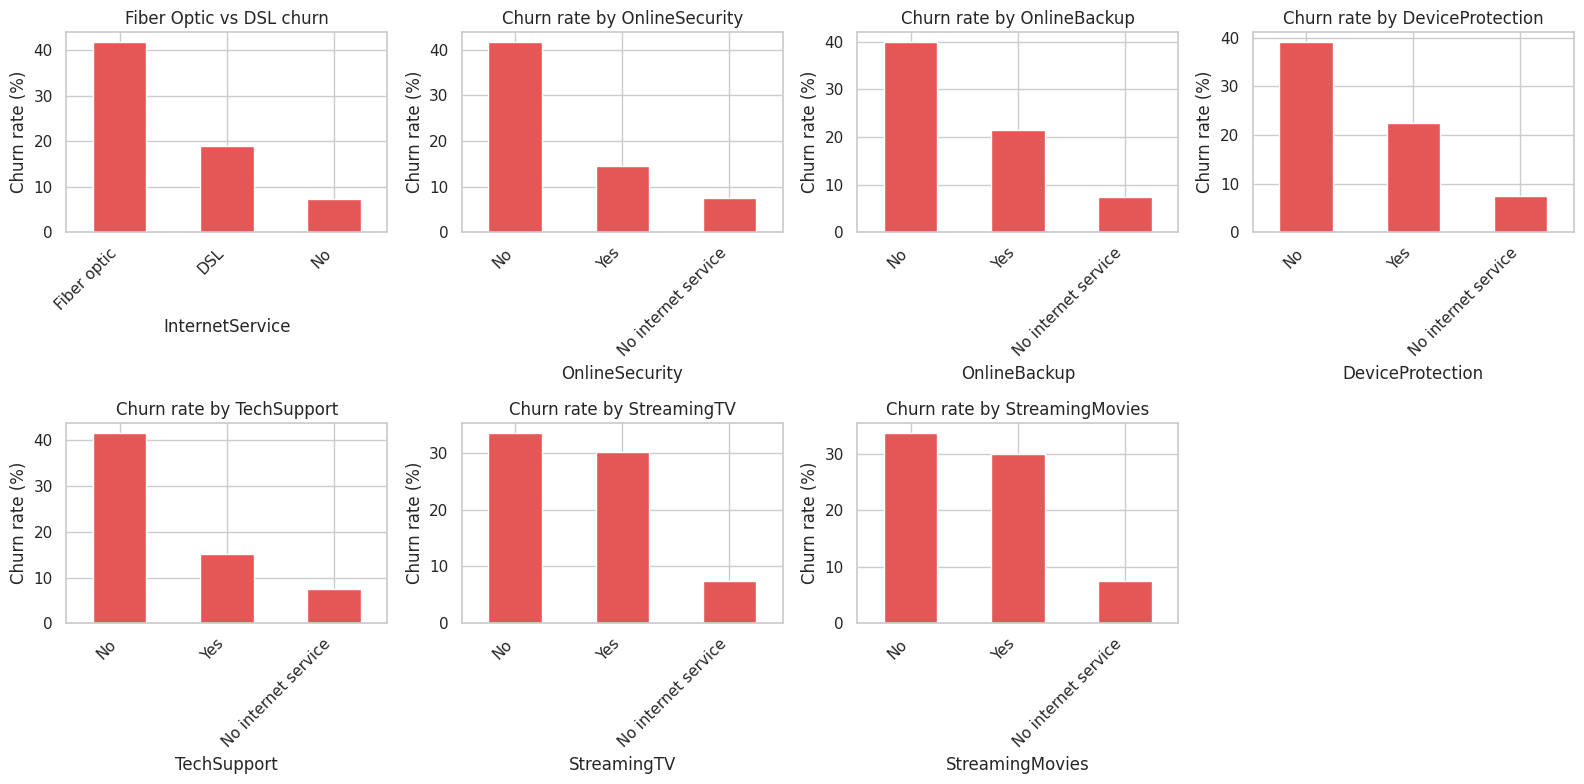

In [12]:
service_cols = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]
service_titles = {
    'InternetService': 'Fiber Optic vs DSL churn',
}
service_results = plot_churn_bars(
    analysis_df,
    service_cols,
    ncols=4,
    figsize=(16, 8),
    titles=service_titles,
)

**People with Fiber Optic are more likely to churn than DSL users.**

Customers without add-ons (Online Security, Tech Support, etc.) churn more often.

## 8. Which Factors Correlate Most with Leaving?

In [13]:
categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod',
]

spread_rows = []
for col in categorical_cols:
    rates = analysis_df.groupby(col)['ChurnFlag'].mean()
    spread_rows.append({
        'Feature': col,
        'LowestChurnPct': rates.min() * 100,
        'HighestChurnPct': rates.max() * 100,
        'SpreadPct': (rates.max() - rates.min()) * 100,
    })

spread_df = pd.DataFrame(spread_rows).sort_values('SpreadPct', ascending=False)
print('Top categorical churn drivers (by churn-rate spread):')
display(spread_df.head(10))

print('\nNumeric correlations with churn:')
display(numeric_corr.abs().sort_values(ascending=False).to_frame('AbsCorrelation'))

# Top examples with actual rates
examples = []
for col in ['Contract', 'InternetService', 'PaymentMethod', 'tenure']:
    if col == 'tenure':
        examples.append(f"tenure: correlation {numeric_corr['tenure']:.2f} (lower tenure -> more churn)")
        continue
    rates = (analysis_df.groupby(col)['ChurnFlag'].mean() * 100).sort_values(ascending=False)
    high_cat, high_rate = rates.index[0], rates.iloc[0]
    low_cat, low_rate = rates.index[-1], rates.iloc[-1]
    examples.append(f"{col}: {high_cat} {high_rate:.1f}% vs {low_cat} {low_rate:.1f}%")

print('\nTop examples:')
for line in examples:
    print(f'- {line}')

Top categorical churn drivers (by churn-rate spread):


,Feature,LowestChurnPct,HighestChurnPct,SpreadPct
12,Contract,2.831858,42.709677,39.877819
5,InternetService,7.404980,41.892765,34.487785
6,OnlineSecurity,7.404980,41.766724,34.361744
9,TechSupport,7.404980,41.635474,34.230493
7,OnlineBackup,7.404980,39.928756,32.523776
8,DeviceProtection,7.404980,39.127625,31.722645
14,PaymentMethod,15.243101,45.285412,30.042311
11,StreamingMovies,7.404980,33.680431,26.275451
10,StreamingTV,7.404980,33.523132,26.118151
13,PaperlessBilling,16.330084,33.565092,17.235009



Numeric correlations with churn:


,AbsCorrelation
tenure,0.352229
TotalCharges,0.199037
MonthlyCharges,0.193356
SeniorCitizen,0.150889



Top examples:
- Contract: Month-to-month 42.7% vs Two year 2.8%
- InternetService: Fiber optic 41.9% vs No 7.4%
- PaymentMethod: Electronic check 45.3% vs Credit card (automatic) 15.2%
- tenure: correlation -0.35 (lower tenure -> more churn)


## 9. Key Findings Summary

In [14]:
summary_points = [
    'Month-to-month contracts churn far more than 1- or 2-year contracts.',
    'People with Fiber Optic are more likely to churn than DSL users.',
    'Electronic check has the highest churn; automatic payment is lowest.',
    'Low tenure strongly correlates with leaving — the first year is critical.',
    'Higher monthly charges correlate with churn.',
    'Lack of add-ons (Online Security, Tech Support) links to higher churn.',
    'Customers without partners or dependents churn more often.',
    'Gender and phone service are weak churn drivers on their own.',
]

print('Key takeaways for modeling (see train.py):')
for i, point in enumerate(summary_points, 1):
    print(f'{i}. {point}')

Key takeaways for modeling (see train.py):
1. Month-to-month contracts churn far more than 1- or 2-year contracts.
2. People with Fiber Optic are more likely to churn than DSL users.
3. Electronic check has the highest churn; automatic payment is lowest.
4. Low tenure strongly correlates with leaving — the first year is critical.
5. Higher monthly charges correlate with churn.
6. Lack of add-ons (Online Security, Tech Support) links to higher churn.
7. Customers without partners or dependents churn more often.
8. Gender and phone service are weak churn drivers on their own.


## 10. Model Performance (from `train.py`)

Metrics are saved to `artifacts/metrics.json` when you run `python train.py`. Run training first if the file is missing.

Model: XGBoost
ROC-AUC: 0.8454
F1 (churn class): 0.6181
Optimal threshold: 0.6
Validation F1 at threshold: 0.6718
scale_pos_weight: 2.7684
Best params: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.8}
Accuracy: 0.7729  # misleading alone due to imbalance

Confusion matrix [[TN, FP], [FN, TP]]:
[[830, 205], [115, 259]]


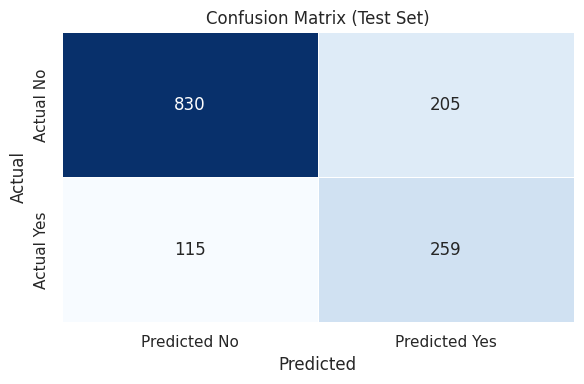

In [15]:
import json
from pathlib import Path

metrics_path = Path("artifacts/metrics.json")

if not metrics_path.exists():
    print("No saved metrics yet. Run: python train.py")
else:
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    print(f"Model: {metrics['model']}")
    print(f"ROC-AUC: {metrics['roc_auc']}")
    print(f"F1 (churn class): {metrics['f1_churn']}")
    print(f"Optimal threshold: {metrics.get('optimal_threshold', 'n/a')}")
    print(f"Validation F1 at threshold: {metrics.get('val_f1_at_threshold', 'n/a')}")
    print(f"scale_pos_weight: {metrics.get('scale_pos_weight', 'n/a')}")
    if "best_params" in metrics:
        print(f"Best params: {metrics['best_params']}")
    print(f"Accuracy: {metrics['accuracy']}  # misleading alone due to imbalance")

    cm = np.array(metrics["confusion_matrix"])
    print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
    print(cm.tolist())

    cm_df = pd.DataFrame(
        cm,
        index=["Actual No", "Actual Yes"],
        columns=["Predicted No", "Predicted Yes"],
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        linecolor="white",
    )
    plt.title("Confusion Matrix (Test Set)")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()